# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra     
**Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

In [1]:
import config
import json
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'
json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_grasshopper_data
Raw data directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_raw_data
Export directory: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports

Search space loaded. The optimizer can control 18 parameters.
Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'Origin_Country', 'Transport_Dist', 'EmissionFactor']

Dataset contains 480 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor
0,NS_00000,0,1500.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,279.66,0.1751
1,NS_00001,0,1500.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,57.45,0.1761
2,NS_00002,0,1500.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,47.51,0.1701
3,NS_00003,0,1500.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,309.29,0.1750
4,NS_00004,0,1500.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,50.79,0.1748


# GEOMETRY

parameters loaded from c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\c11_params.py
GRID: 2x2, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

Geometry: 13 nodes, 32 members
Length range [m]: 1.681 - 4.313


,edge_id,V1,V2,length_m
0,e0,0,1,3.750
1,e1,0,3,3.000
2,e2,1,2,2.250
3,e3,1,4,3.092
4,e4,2,5,3.000


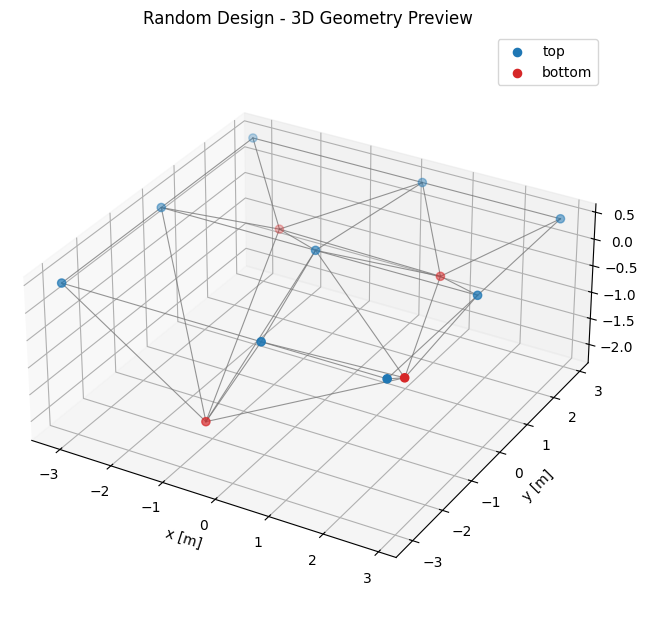

In [2]:
import importlib
import matplotlib.pyplot as plt
import c23_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# Feasibility check

In [3]:
import importlib
from workflows import c25_stage_feasibility as stage_feasibility

importlib.reload(stage_feasibility)

MODEL_PREFIX = "ID20260418_215020_LR0.0005_EP100_R0.99_F6"

feasibility_out = stage_feasibility.run_feasibility_stage(
    df_input_stock=df_input_stock,
    df_vertices=df_vertices,
    df_edges=df_edges,
    model_prefix=MODEL_PREFIX,
    gnn_margin=1.10,
    utilization_threshold=1.00,
    export_slots_path=None,
    force_mode="surrogate",
)

# Compatibility variables used by downstream cost/milp cells
SURROGATE_BUNDLE = feasibility_out["bundle"]
df_forces = feasibility_out["df_forces"]
df_slots = feasibility_out["df_slots"]
df_utilization_long = feasibility_out["df_utilization_long"]
df_utilization_matrix = feasibility_out["df_utilization_matrix"]
df_utilization_matrix_values = feasibility_out["df_utilization_matrix_values"]
df_feasibility_matrix = feasibility_out["df_feasibility_matrix"]
df_feasibility_matrix_values = feasibility_out["df_feasibility_matrix_values"]
df_safe_options = feasibility_out["df_safe_options"]
df_failure_reasons = feasibility_out["df_failure_reasons"]
feasibility_summary = feasibility_out["summary"]

print(
    f"C25 feasibility: {feasibility_summary['slots']} slots x {feasibility_summary['stock_items']} stock, "
    f"feasible pairs={feasibility_summary['feasible_pairs']}/{feasibility_summary['total_pairs']} "
    f"(utilization <= {feasibility_summary['utilization_threshold']:.2f})"
)
display(df_slots.head(5))
display(df_utilization_matrix.head(5))

# Export feasibility artifacts for downstream reporting/auditing
export_dir = config.EXPORT_PATH
export_dir.mkdir(parents=True, exist_ok=True)

target_edge_for_failure = "e24"
feasibility_matrix_path = export_dir / "c25_feasibility_matrix.csv"
structure_slots_path = export_dir / "c25_structure_slots.csv"
utilization_matrix_path = export_dir / "c25_utilization_matrix.csv"
failure_reasons_path = export_dir / f"c25_failure_reasons_edge_{target_edge_for_failure}.csv"

df_feasibility_matrix.to_csv(feasibility_matrix_path, index=True)
df_slots.to_csv(structure_slots_path, index=False)
df_utilization_matrix.to_csv(utilization_matrix_path, index=True)

failure_reasons_edge = df_failure_reasons[
    df_failure_reasons["edge_id"].astype(str).str.strip().str.lower() == target_edge_for_failure.lower()
]
failure_reasons_edge.to_csv(failure_reasons_path, index=False)

print(f"Exported feasibility matrix: {feasibility_matrix_path}")
print(f"Exported structure slots: {structure_slots_path}")
print(f"Exported utilization matrix: {utilization_matrix_path}")
print(
    f"Exported failure reasons for {target_edge_for_failure}: {failure_reasons_path} "
    f"(rows={len(failure_reasons_edge)})"
)

c:\Users\jaspe\Documents\PyEnvs\thesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99_F6
Device: cpu
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1
C25 feasibility: 32 slots x 480 stock, feasible pairs=7002/15360 (utilization <= 1.00)


,edge_id,length_m,axial_force_kn,Length_Req,Depth_Req,Width_Req,governing_utilization,Area_Req
0,e0,3.750000,-38.188484,3750,300.0,75.0,0.895031,0.022500
1,e1,3.000000,-19.787970,3000,300.0,50.0,0.972906,0.015000
2,e2,2.250000,-11.043121,2250,100.0,50.0,0.966130,0.005000
3,e3,3.092329,81.712173,3092,175.0,63.0,0.948455,0.011025
4,e4,3.000000,14.788196,3000,100.0,38.0,0.496878,0.003800


,NS_00000,NS_00001,NS_00002,NS_00003,NS_00004,NS_00005,NS_00006,NS_00007,NS_00008,NS_00009,...,RS_00029,RS_00030,RS_00031,RS_00032,RS_00033,RS_00034,RS_00035,RS_00036,RS_00037,RS_00038
e0,20.132450,8.943521,4.532450,2.723591,1.189080,13.399579,5.949495,3.013262,1.809521,0.788931,...,7.262421,3.740127,1.751194,1.300096,7.262421,3.740127,1.751194,1.300096,7.262421,3.740127
e1,6.744941,3.002308,1.526574,0.921686,0.410030,4.475002,1.988854,1.009446,0.608390,0.269201,...,2.426733,1.248764,0.579963,0.432439,2.426733,1.248764,0.579963,0.432439,2.426733,1.248764
e2,2.155645,0.966130,0.497074,0.305458,0.146238,1.426240,0.637658,0.327158,0.200463,0.095353,...,0.777305,0.402135,0.187750,0.142479,0.777305,0.402135,0.187750,0.142479,0.777305,0.402135
e3,2.745498,2.087352,1.657298,1.392653,1.045320,1.831409,1.392653,1.105965,0.929557,0.698042,...,1.772467,1.304405,0.828024,0.793709,1.772467,1.304405,0.828024,0.793709,1.772467,1.304405
e4,0.496878,0.379116,0.302159,0.254674,0.192177,0.333316,0.254674,0.203090,0.171360,0.129741,...,0.324130,0.239910,0.154264,0.148094,0.324130,0.239910,0.154264,0.148094,0.324130,0.239910


Exported feasibility matrix: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_feasibility_matrix.csv
Exported structure slots: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_structure_slots.csv
Exported utilization matrix: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_utilization_matrix.csv
Exported failure reasons for e24: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\c25_failure_reasons_edge_e24.csv (rows=142)


# COST, MATCHING AND FITNESS

In [4]:
import importlib
import pandas as pd
import config
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c28_stage_fitness as stage_fitness

importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)

# -------------------------------
# STEP 1: COST MATRIX STAGE
# -------------------------------
target_slot_for_analysis = "e24"

cost_out = stage_cost.run_cost_matrix_stage(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    df_utilization_matrix=df_utilization_matrix_values if "df_utilization_matrix_values" in globals() else df_utilization_matrix,
    utilization_threshold=1.00,
    export_cost_matrix_path=config.EXPORT_PATH / "final_cost_matrix.csv",
    include_threshold_sweep=True,
    utilization_threshold_sweep=(1.00, 1.25, 1.50),
    export_slot_analysis=True,
    target_slot_for_analysis=target_slot_for_analysis,
    export_dir=config.EXPORT_PATH,
    quiet=True,
)

cost_matrix = cost_out["cost_matrix"]
enriched_stock = cost_out["enriched_stock"]
df_logs = cost_out["df_logs"]
df_cost_matrix_display = cost_out["df_cost_matrix_display"]
df_threshold_sweep = cost_out["df_threshold_sweep"]
slot_analysis = cost_out["slot_analysis"]
cost_summary = cost_out["summary"]

print(
    f"Cost matrix: {cost_summary['slots']} slots x {cost_summary['stock_items']} stock, "
    f"valid={cost_summary['valid_pairs']}/{cost_summary['total_pairs']} "
    f"(pruned={cost_summary.get('pruned_pairs', 0)}), "
    f"utilization_mode={cost_summary.get('utilization_mode', 'unknown')}"
)

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    print("Threshold sweep summary:")
    display(df_threshold_sweep)

if slot_analysis is not None:
    print(f"Detailed slot analysis exported: {slot_analysis['analysis_export_path']}")

# -------------------------------
# STEP 2: MILP STAGE
# -------------------------------
print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    solver_msg=False,
    raise_on_infeasible_slots=True,
)

status = milp_out["status"]
df_results = milp_out["df_results"]
total_cost = milp_out["total_cost"]
milp_summary = milp_out["summary"]

print(
    f"MILP setup: {milp_summary['reclaimed_items']} reclaimed + "
    f"{milp_summary['new_items']} new stock items for {milp_summary['slots']} slots"
)
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if len(df_results) > 0:
    display(df_results.head(10))

# -------------------------------
# STEP 3: FITNESS STAGE
# -------------------------------
fitness_out = stage_fitness.run_fitness_stage(
    df_results=df_results,
    total_cost=total_cost,
    status=status,
    export_fitness_json_path=config.EXPORT_PATH / "fitness_result.json",
    export_fitness_csv_path=config.EXPORT_PATH / "fitness_result.csv",
)

fitness_result = fitness_out["fitness_result"]
print("Fitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible: {fitness_result.get('is_feasible', 'n/a')}")

Cost matrix: 32 slots x 480 stock, valid=10718/15360 (pruned=4642), utilization_mode=c25_feasibility_matrix
Threshold sweep summary:


,threshold,valid,total,ratio,mean_cost
0,1.00,10718,15360,0.697786,2.635192
1,1.25,11347,15360,0.738737,2.635192
2,1.50,11825,15360,0.769857,2.635192


Detailed slot analysis exported: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\depth_analysis_e24.csv
Starting MILP optimizer...
MILP setup: 38 reclaimed + 442 new stock items for 32 slots
MILP status: Optimal
Total assignment cost: 79.50


,edge_id,assigned_timber,CO2_Penalty
0,e0,NS_00326,9.12
1,e1,RS_00016,0.50
2,e2,NS_00326,1.22
3,e3,RS_00023,0.95
4,e4,RS_00025,0.41
5,e5,RS_00034,0.46
6,e6,RS_00031,0.74
7,e7,RS_00037,0.43
8,e8,RS_00001,0.29
9,e9,RS_00029,0.65


TypeError: run_fitness_stage() got an unexpected keyword argument 'status'

In [ ]:
# Verify dimension columns exist
inv_dims = [col for col in df_input_stock.columns if col.lower() in ['width', 'depth', 'length']]
slot_reqs = [col for col in df_slots.columns if 'Req' in col]
print(f"Inventory dims: {inv_dims} | Slot reqs: {slot_reqs}")

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# LITERATURE

### COST MATRIX
We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

### MATCHING ALGORITHM / MILP
The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

### MULTI-OBJECTIVE FITNESS FUNCTION

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

All metrics are normalized to [0, 1] using precomputed dataset-driven extremes ($\mathcal{C}_{max}$, $\mathcal{R}_{max}$, $\mathcal{W}_{max}$).

**Design philosophy**: The MILP cost matrix already accounts for all physical and geometric infeasibilities (by returning ∞ for impossible assignments). This means the upper-level fitness function does NOT need a conditional fallback loop. Instead, we can directly minimize a weighted multi-objective sum.

**Sign convention**:
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- Negative coefficient on reuse: higher reuse rate → lower (better) fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Typical design trade-offs**:
- High ω₁ (cost weight): prioritize LCA minimization across all materials
- High ω₂ (reuse weight): prioritize reclaimed material recovery
- High ω₃ (waste weight): prioritize cutting efficiency